# Continuous Time Quantum Walks

## Ring Topology

Once again, we introduce the position operator, and the evolution hamiltonian:

In [1]:
import numpy as np                          # linear algebra

ring_size = 200

x = np.zeros(ring_size, dtype=np.complex128)  # position vector
x[ring_size//2] = 1

state = x

Tails = -1*np.eye(ring_size, k=-1, dtype=np.complex128)
Heads = -1*np.eye(ring_size, k=1, dtype=np.complex128)
Diag = 2*np.eye(ring_size, dtype=np.complex128)

a = np.zeros((ring_size, ring_size), dtype=np.complex128)
a[ring_size-1, 0] = -1

b = np.zeros((ring_size, ring_size), dtype=np.complex128)
b[0, ring_size-1] = -1

gamma = 0.5

Shift = gamma * (Tails + Heads + Diag + a + b) # sum of all the shifts caused by heads or tails, plus the boundary conditions to make it an actual ring

def Shrodinger(t, state) : 
    dstate =-1j * Shift@state
    return dstate

We import a differential equation solver.

In [2]:
from scipy.integrate import solve_ivp

endtime = 50
t_eval = np.arange(0, endtime, 0.1)
sol = solve_ivp(Shrodinger, [0, endtime], state, t_eval=t_eval, method='RK45')

We measure the position probabilities and plot the final results.

In [3]:
def Measure_pos(state):
    positions = np.zeros(ring_size)

    for i, x in enumerate(state):
        if x != 0:
            positions[i] += abs(x)**2

    return positions

pos = Measure_pos(sol.y[:, -1])

Text(0.5, 1.0, 'Probability distribution at t=50')

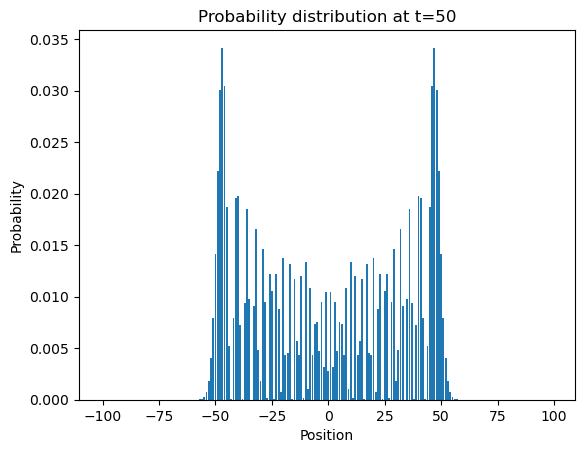

In [4]:
import matplotlib.pyplot as plt

plt.bar(np.arange(len(pos)) - ring_size//2, pos)

plt.xlabel("Position")
plt.ylabel("Probability")
plt.title('Probability distribution at t=50')

Since we have the Hamiltonian, we can obtain the final state by just calculating

$$ \ket{\psi(t)} = \hat{U}(t) \ket{\psi(0)}$$

with $\hat{U}(t) = e^{-i \hat{H} t}$ the time evolution operator.

In [5]:
from scipy.linalg import expm

def Evol_vector(t, state):
    return expm(-1j * Shift * t) @ state

In [6]:
f_state = Evol_vector(50, state)

In [7]:
pos_operator = Measure_pos(f_state)

Text(0.5, 1.0, 'Operator evolved evolution')

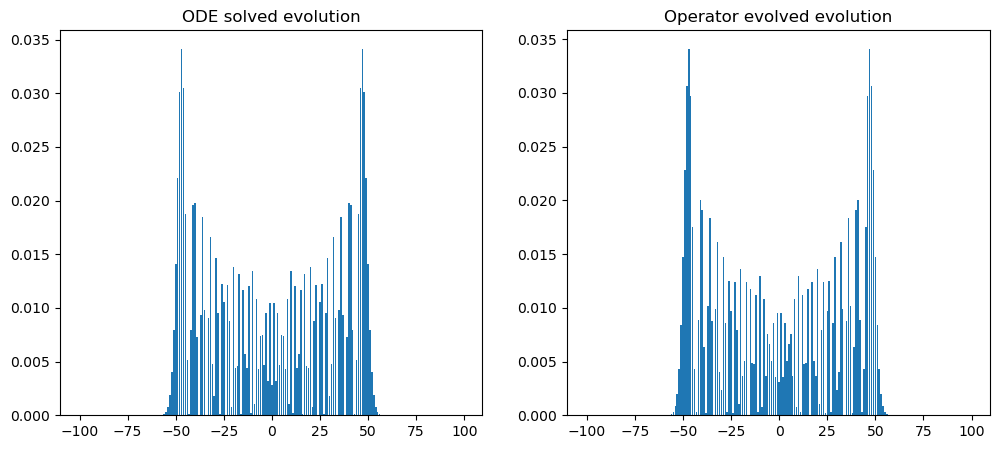

In [8]:
import matplotlib.pyplot as plt

fig, (p1, p2) = plt.subplots(1, 2, figsize=(12, 5))

p1.bar(np.arange(len(pos)) - ring_size//2, pos)

p1.set_title("ODE solved evolution")

p2.bar(np.arange(len(pos_operator)) - ring_size//2, pos_operator)

p2.set_title("Operator evolved evolution")

## Density Matrix

The reason is that we can more easily understand the dephasing, which means, the change from superposition to statistical mixture.

In [3]:
import numpy as np                          # linear algebra

ring_size = 200

x = np.zeros(ring_size, dtype=np.complex128)  # position vector
x[ring_size//2] = 1

state = np.outer(x, x)

Tails = -1*np.eye(ring_size, k=-1, dtype=np.complex128)
Heads = -1*np.eye(ring_size, k=1, dtype=np.complex128)
Diag = 2*np.eye(ring_size, dtype=np.complex128)

a = np.zeros((ring_size, ring_size), dtype=np.complex128)
a[ring_size-1, 0] = -1

b = np.zeros((ring_size, ring_size), dtype=np.complex128)
b[0, ring_size-1] = -1

gamma = 0.5

Shift = gamma * (Tails + Heads + Diag + a + b) # sum of all the shifts caused by heads or tails, plus the boundary conditions to make it an actual ring

def VNeumann(t, state) :

    rho = state.reshape((ring_size, ring_size))
    dstate = -1j * (Shift @ rho - rho @ Shift)
    return dstate.flatten()

In [34]:
def Measure_pos(state):
   
    return np.real(np.diag(state.reshape((ring_size, ring_size))))

# The original code had a loop in which I'd build a projector on every position
# And then calculate the trace, put it in another vector, and return that.

# But just taking the real part of the diagonal of the matrix is the exact same thing, so...

Once again, first we integrate the equation, and then we evolve it via unitary operator. One is way faster (and probably way more accurate) than the other...

In [17]:
from scipy.integrate import solve_ivp

endtime = 50
t_eval = np.arange(0, endtime, 0.1)
sol = solve_ivp(VNeumann, [0, endtime], state.flatten(), t_eval=t_eval, method='RK45')

In [18]:
pos = Measure_pos(sol.y[:, -1])

In [20]:
from scipy.linalg import expm

def Evol(t, state):
    operator = expm(-1j * Shift * t)
    return operator @ state @ operator.conj().T

In [21]:
f_state = Evol(50, state)
pos_operator = Measure_pos(f_state)

Text(0.5, 1.0, 'Operator evolved evolution')

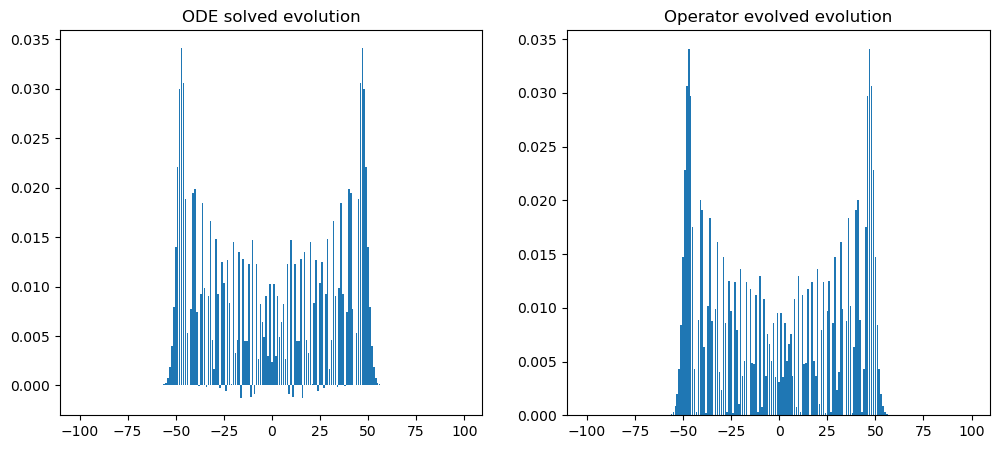

In [22]:
import matplotlib.pyplot as plt

fig, (p1, p2) = plt.subplots(1, 2, figsize=(12, 5))

p1.bar(np.arange(len(pos)) - ring_size//2, pos)

p1.set_title("ODE solved evolution")

p2.bar(np.arange(len(pos_operator)) - ring_size//2, pos_operator)

p2.set_title("Operator evolved evolution")

Somehow, the integration produced negative probabilities. We figured out which approach is better.